# Polynomial & Logistic Regression



In [10]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

np.random.seed(42)
plt.rcParams["figure.figsize"] = (6, 4)

## Part 1: Polynomial Regression

### Step 1 — Create a simple curved dataset

Same shape as the slides: `y = 0.5x² + x + 2 + noise`. A straight line can't follow this,
so it's a good demo case.

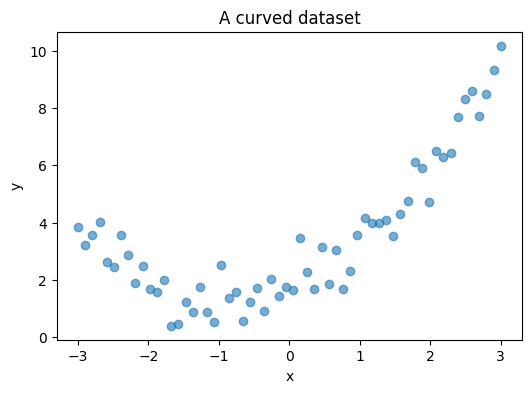

In [11]:
x = np.linspace(-3, 3, 60).reshape(-1, 1)
y = 0.5 * x**2 + x + 2 + np.random.randn(60, 1) * 0.7

plt.scatter(x, y, alpha=0.6)
plt.xlabel("x")
plt.ylabel("y")
plt.title("A curved dataset")
plt.show()

### Step 2 — Try a straight line first

Fit ordinary `LinearRegression` directly on `x`, and see how well (or badly) a straight
line fits a curved dataset.

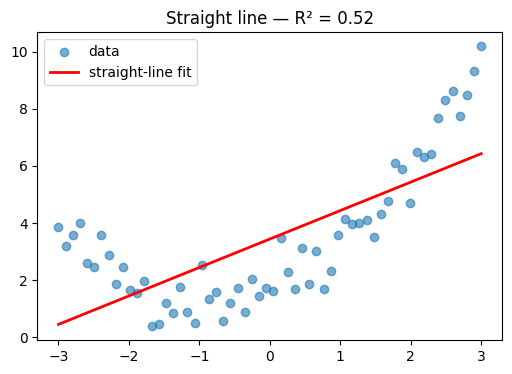

In [12]:
lin_reg = LinearRegression()
lin_reg.fit(x, y)
y_pred_line = lin_reg.predict(x)

plt.scatter(x, y, alpha=0.6, label="data")
plt.plot(x, y_pred_line, "r-", linewidth=2, label="straight-line fit")
plt.legend()
plt.title(f"Straight line — R² = {r2_score(y, y_pred_line):.2f}")
plt.show()

### Step 3 — Add a squared term

`PolynomialFeatures(degree=2)` turns each `x` into `[x, x²]`. Fitting ordinary
`LinearRegression` on those two columns lets the model draw a curve instead of a line.

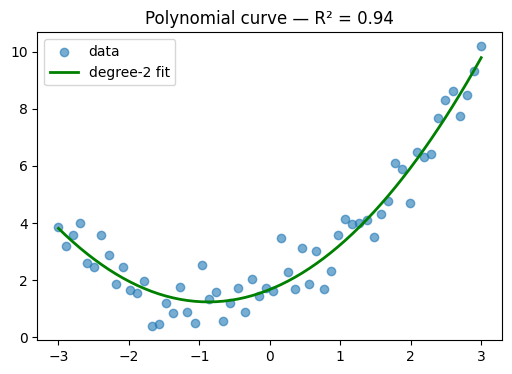

In [17]:
poly = PolynomialFeatures(degree=2, include_bias=False)
x_poly = poly.fit_transform(x)   # each row is now [x, x**2]

poly_reg = LinearRegression()
poly_reg.fit(x_poly, y)
y_pred_curve = poly_reg.predict(x_poly)

plt.scatter(x, y, alpha=0.6, label="data")
plt.plot(x, y_pred_curve, "g-", linewidth=2, label="degree-2 fit")
plt.legend()
plt.title(f"Polynomial curve — R² = {r2_score(y, y_pred_curve):.2f}")
plt.show()

### Step 4 — Compare

R² closer to 1 means a better fit. The polynomial model should score noticeably higher
than the straight line on this curved data.

In [18]:
print("Straight line   R²:", round(r2_score(y, y_pred_line), 3))
print("Polynomial (deg 2) R²:", round(r2_score(y, y_pred_curve), 3))
print()
print("Learned coefficients (intercept, x, x²):")
print(poly_reg.intercept_, poly_reg.coef_)
print("(true values were roughly: 2, 1, 0.5)")

Straight line   R²: 0.519
Polynomial (deg 2) R²: 0.939

Learned coefficients (intercept, x, x²):
[1.67744121] [[0.99508316 0.56909142]]
(true values were roughly: 2, 1, 0.5)


**Try it yourself:** change `degree=2` to `degree=1` (should match the straight line) or
`degree=15` (watch it start overfitting — a wigglier curve chasing noise).

## Part 2: Logistic Regression

### Step 1 — Create a simple 2-class dataset

Two blobs of points, one per class, with a bit of overlap so the classifier has
something real to figure out.

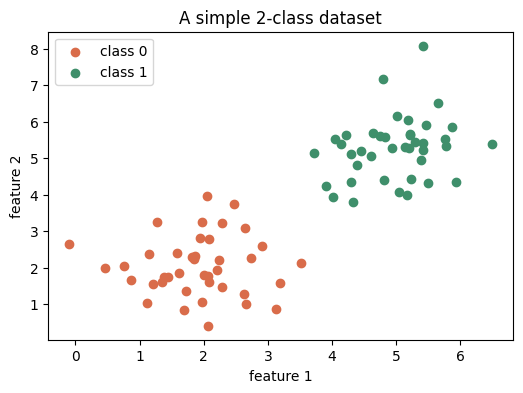

In [ ]:
n = 40
class0 = np.random.randn(n, 2) * 0.8 + [2, 2]
class1 = np.random.randn(n, 2) * 0.8 + [5, 5]

X = np.vstack([class0, class1])
y_class = np.array([0]*n + [1]*n)

plt.scatter(class0[:, 0], class0[:, 1], color="#D96C4A", label="class 0")
plt.scatter(class1[:, 0], class1[:, 1], color="#3F8F6B", label="class 1")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.legend()
plt.title("A simple 2-class dataset")
plt.show()

### Step 2 — Fit a Logistic Regression model

Same `.fit()` pattern as any other scikit-learn model — just with a classifier instead
of a regressor.

In [ ]:
log_reg = LogisticRegression()
log_reg.fit(X, y_class)

print("Training accuracy:", log_reg.score(X, y_class))

Training accuracy: 1.0


### Step 3 — Predict new points

`.predict()` gives the class; `.predict_proba()` gives the probability behind that
decision.

In [ ]:
new_points = np.array([[2, 2], [5, 5], [3.5, 3.5]])

print("Predicted classes:", log_reg.predict(new_points))
print("Predicted probabilities [P(class 0), P(class 1)]:")
print(log_reg.predict_proba(new_points).round(2))

Predicted classes: [0 1 0]
Predicted probabilities [P(class 0), P(class 1)]:
[[0.99 0.01]
 [0.01 0.99]
 [0.52 0.48]]


Notice the point `[3.5, 3.5]` — right between the two blobs — should come back close
to 50/50. That's the decision boundary in action.

### Step 4 — Visualize the decision boundary

Predict across a fine grid covering the whole plot, then color the background by
predicted class. The line where the color changes *is* the decision boundary.

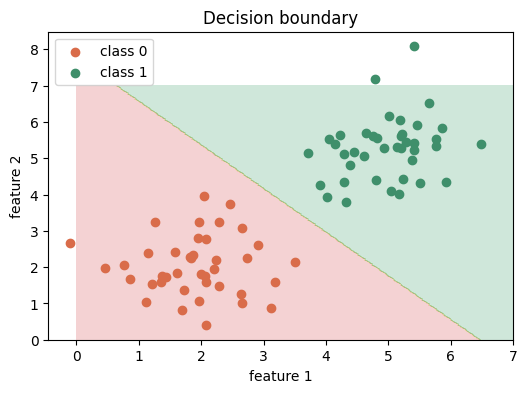

In [19]:
xx, yy = np.meshgrid(np.linspace(0, 7, 300), np.linspace(0, 7, 300))
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_preds = log_reg.predict(grid_points).reshape(xx.shape)

plt.contourf(xx, yy, grid_preds, alpha=0.2, cmap="RdYlGn")
plt.scatter(class0[:, 0], class0[:, 1], color="#D96C4A", label="class 0")
plt.scatter(class1[:, 0], class1[:, 1], color="#3F8F6B", label="class 1")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.legend()
plt.title("Decision boundary")
plt.show()

**Try it yourself:** move the two blob centers closer together (e.g. `[3, 3]` and
`[4, 4]`) and re-run — watch the boundary and the training accuracy change as the classes
start overlapping more.